In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Iris.csv')
df.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
98,99,5.1,2.5,3.0,1.1,Iris-versicolor
35,36,5.0,3.2,1.2,0.2,Iris-setosa
117,118,7.7,3.8,6.7,2.2,Iris-virginica
83,84,6.0,2.7,5.1,1.6,Iris-versicolor
89,90,5.5,2.5,4.0,1.3,Iris-versicolor


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


In [7]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
df.shape

(150, 6)

In [9]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

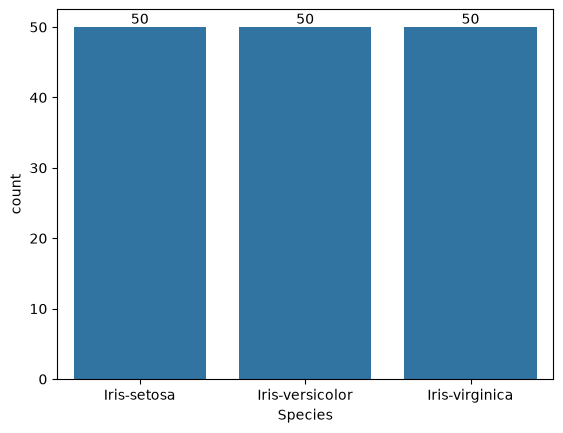

In [10]:
bar = sns.barplot(df['Species'].value_counts())
bar = bar.bar_label(bar.containers[0], fontsize=10)

<Axes: >

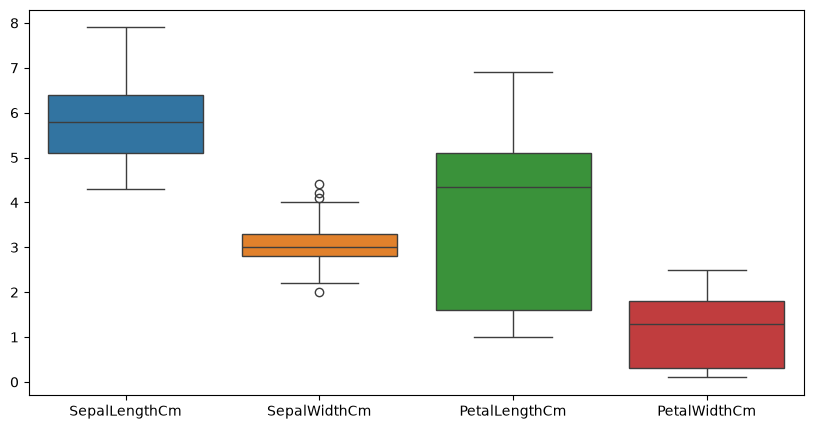

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(df.drop(columns=['Species','Id']))

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

encoder =  LabelEncoder()
df['Outcome'] = encoder.fit_transform(df['Species'])

In [13]:
df.sample(6)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Outcome
105,106,7.6,3.0,6.6,2.1,Iris-virginica,2
68,69,6.2,2.2,4.5,1.5,Iris-versicolor,1
36,37,5.5,3.5,1.3,0.2,Iris-setosa,0
73,74,6.1,2.8,4.7,1.2,Iris-versicolor,1
40,41,5.0,3.5,1.3,0.3,Iris-setosa,0
8,9,4.4,2.9,1.4,0.2,Iris-setosa,0


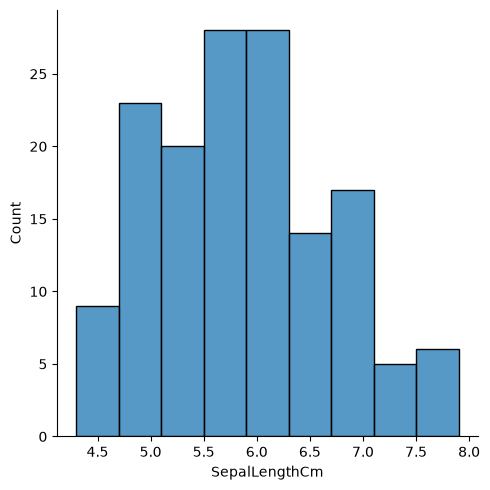

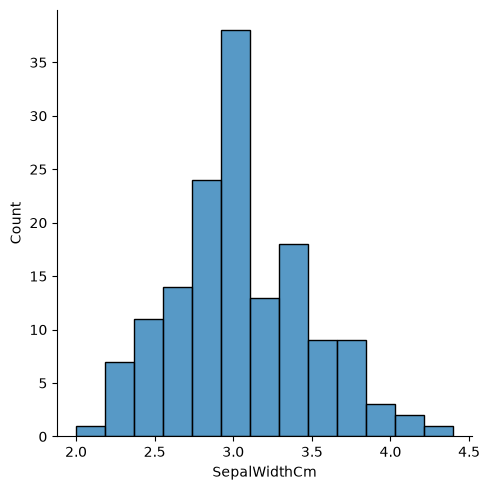

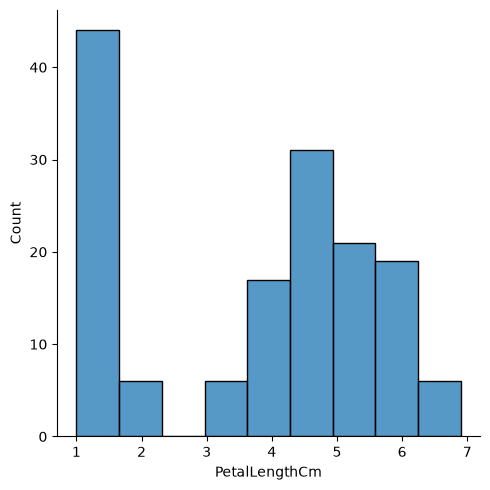

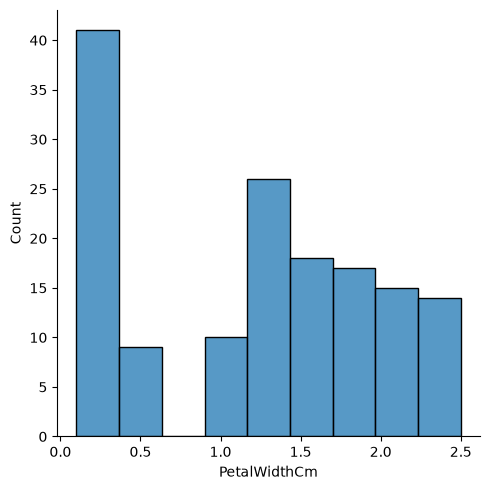

In [14]:
y = df['Outcome']
X = df.drop(columns=['Species','Id','Outcome'])

for col in X.columns:
    sns.displot(df[col])

In [15]:
X.corr()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


<Axes: >

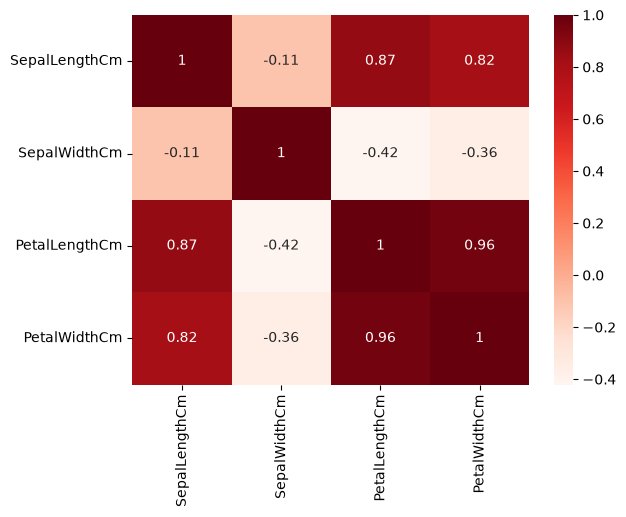

In [16]:
sns.heatmap(X.corr() , annot=True , cmap='Reds')

In [17]:
# linear regression model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
model = LogisticRegression()
model.fit(X_train, y_train)
# accuracy score of the model on training data
model.score(X_train, y_train)


0.9714285714285714

In [18]:
# accuracy score of the model on testing data
model.score(X_test, y_test)

0.9333333333333333

In [19]:
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

In [20]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       0.95      0.97      0.96        40
           2       0.97      0.94      0.95        33

    accuracy                           0.97       105
   macro avg       0.97      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105



In [21]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.77      1.00      0.87        10
           2       1.00      0.82      0.90        17

    accuracy                           0.93        45
   macro avg       0.92      0.94      0.92        45
weighted avg       0.95      0.93      0.93        45



In [22]:
cm = confusion_matrix(y_train, pred_train)

<Axes: >

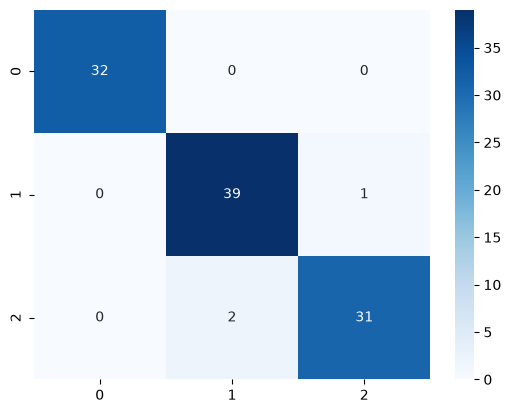

In [23]:
sns.heatmap(cm, annot=True, cmap='Blues')

In [24]:
# knn
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
# accuracy score of the model on training data
model.score(X_train, y_train)


0.9809523809523809

In [25]:
# accuracy score of the model on testing data
model.score(X_test, y_test)

0.9555555555555556

In [26]:
# svm
from sklearn.svm import SVC
model = SVC(kernel = 'linear')
model.fit(X_train, y_train)
# accuracy score of the model on training data
model.score(X_train, y_train)

0.9904761904761905

In [27]:
# accuracy score of the model on testing data
model.score(X_test, y_test)

0.9555555555555556

In [28]:
# MLP
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(22, 8), max_iter=10000)
model.fit(X_train, y_train)
# accuracy score of the model on training data
model.score(X_train, y_train)

0.9904761904761905

In [29]:
# accuracy score of the model on testing data
model.score(X_test, y_test)

0.9777777777777777

In [30]:
# decision tree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
# accuracy score of the model on training data
model.score(X_train, y_train)

1.0

In [31]:
# accuracy score of the model on testing data
model.score(X_test, y_test)

0.9555555555555556

In [32]:
importances = model.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index=columns, columns=['Importance']).sort_values(by='Importance', ascending=False)

In [33]:
importance_df

,Importance
PetalWidthCm,0.892201
PetalLengthCm,0.065437
SepalWidthCm,0.028720
SepalLengthCm,0.013642


In [34]:
importance_df  = importance_df.reset_index()
importance_df

,index,Importance
0,PetalWidthCm,0.892201
1,PetalLengthCm,0.065437
2,SepalWidthCm,0.028720
3,SepalLengthCm,0.013642


<Axes: xlabel='Importance', ylabel='index'>

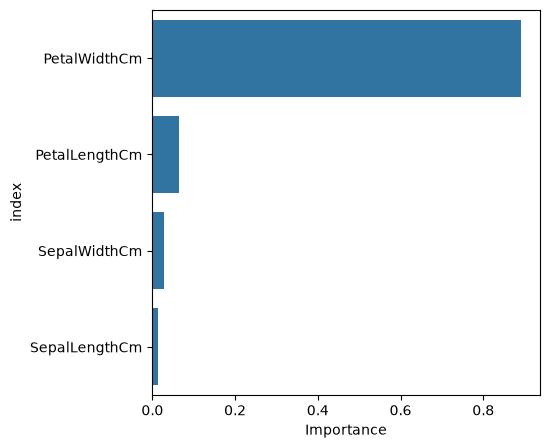

In [35]:
plt.figure(figsize = (5,5))
sns.barplot(data=importance_df , y='index', x='Importance', orient='h')

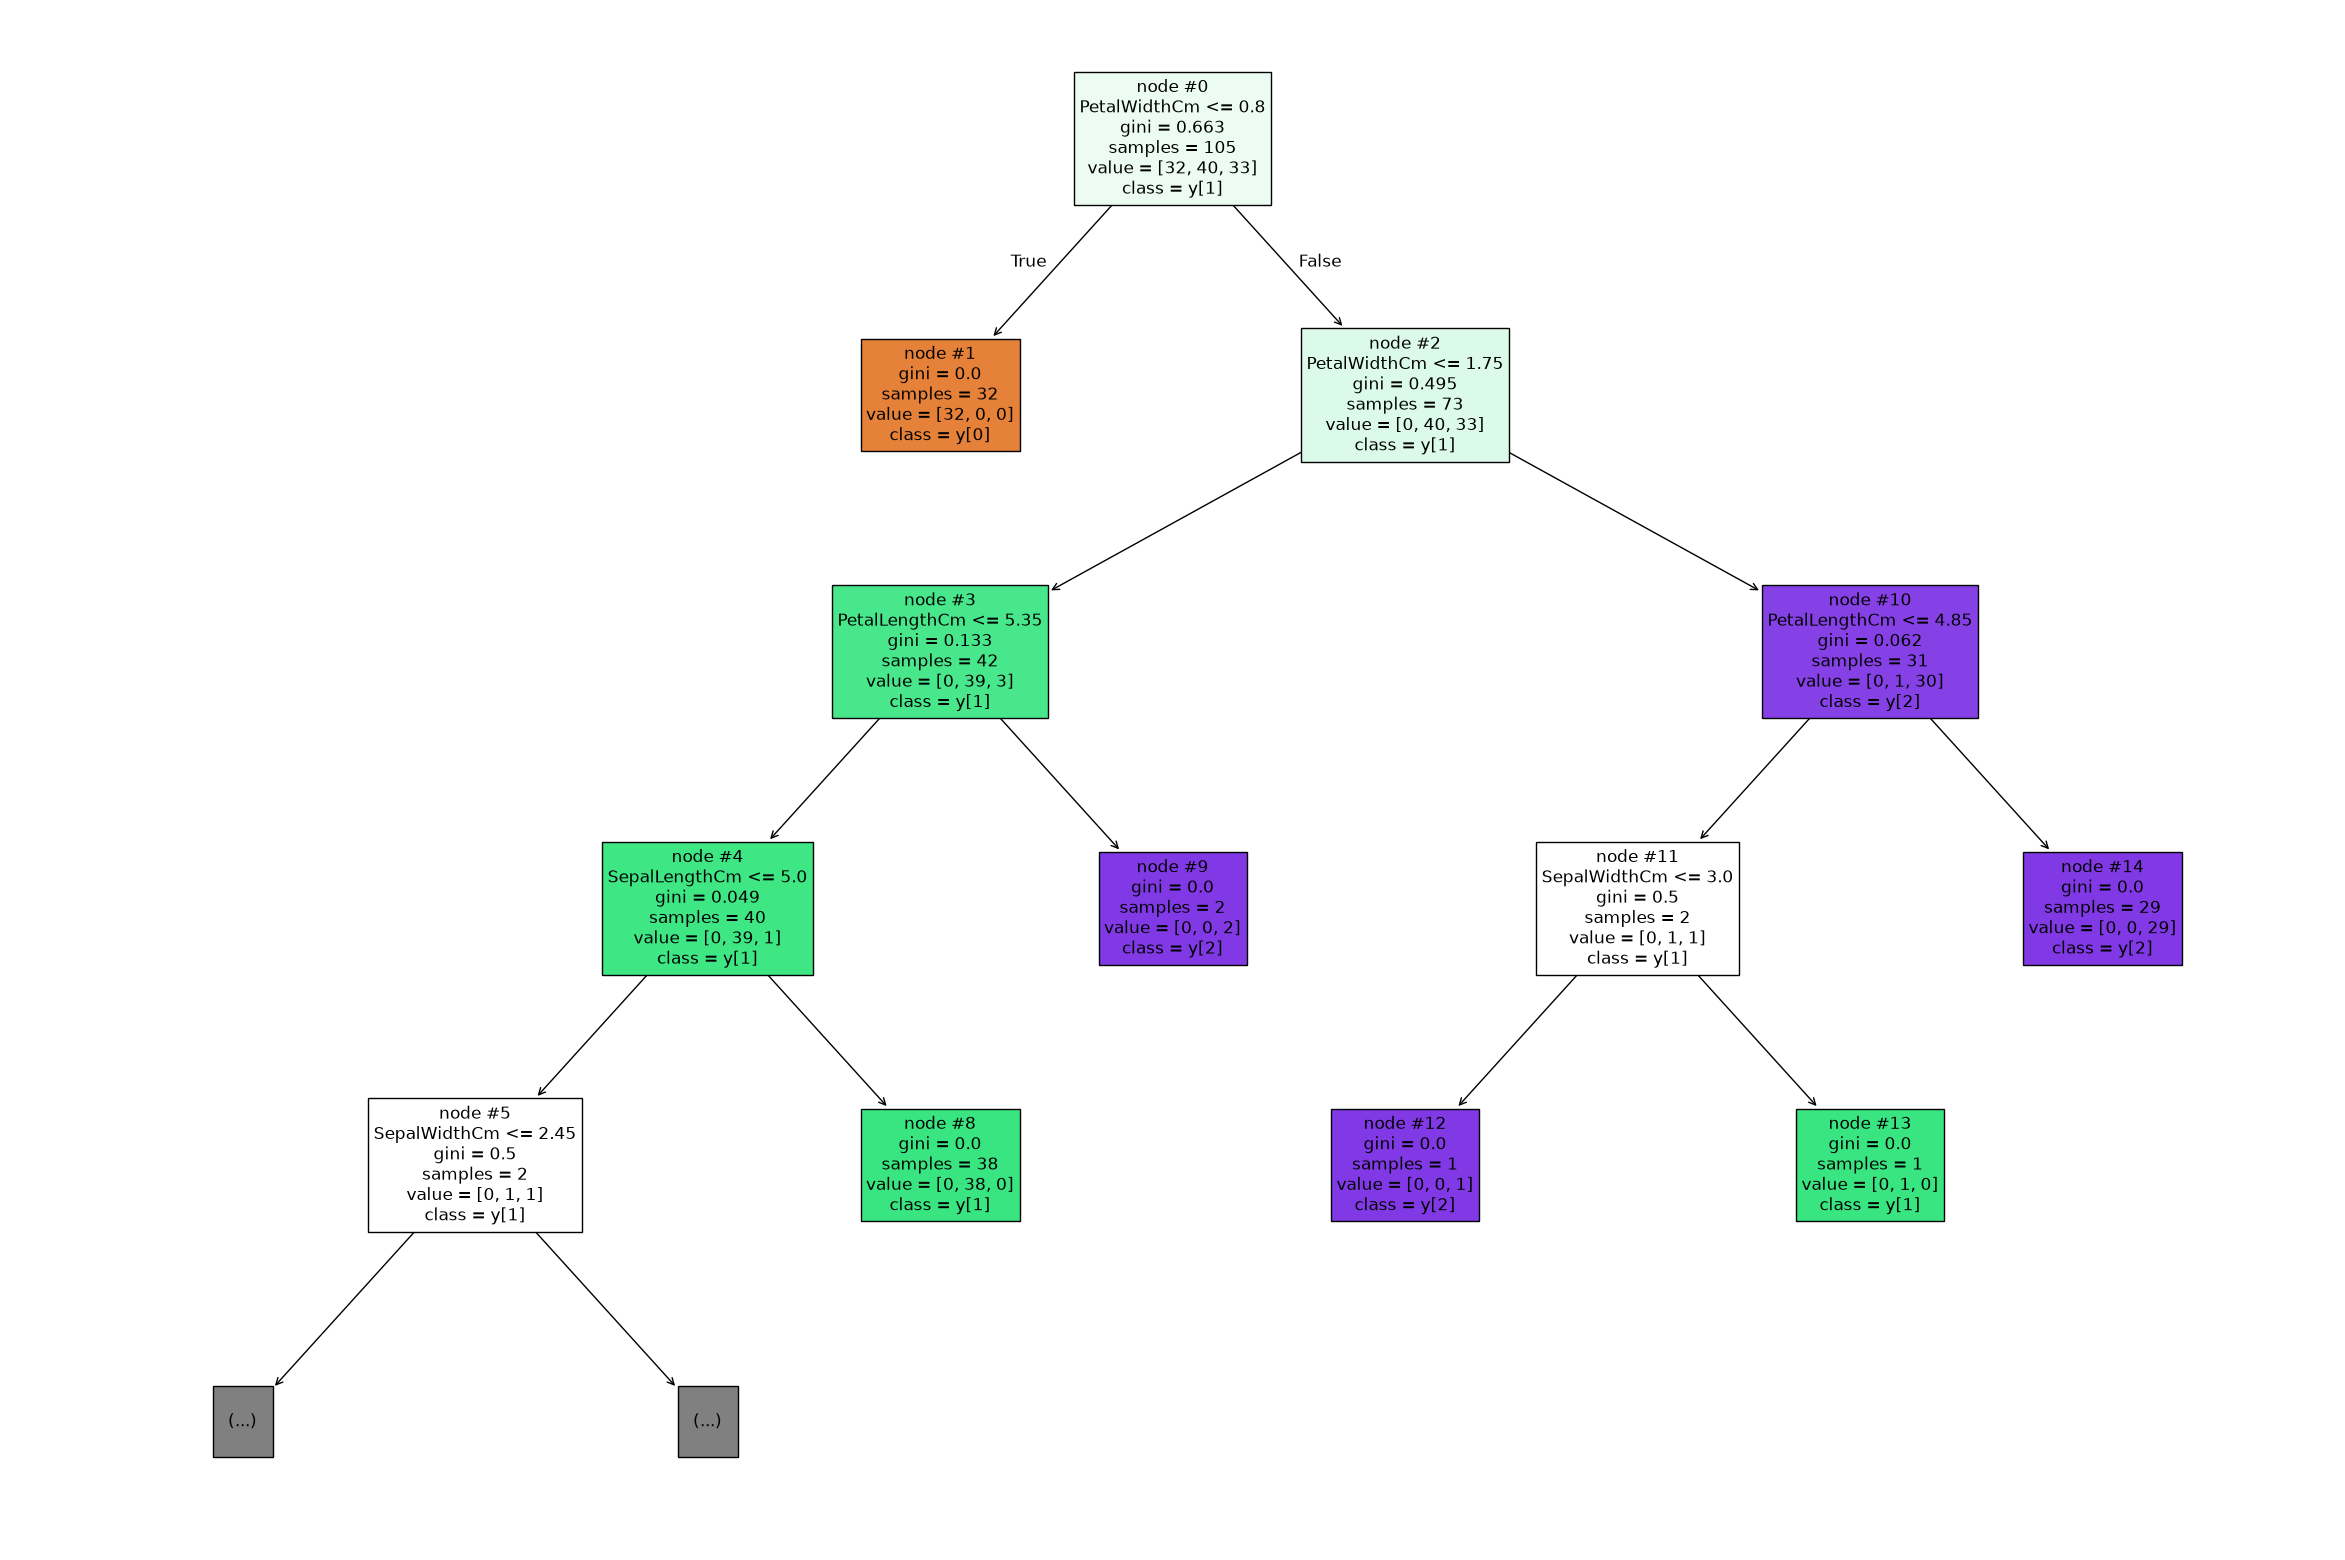

In [36]:
from sklearn import tree
features = list(X.columns)
plt.figure(figsize=(30,20))
tree.plot_tree(model, max_depth=4, feature_names=features, filled=True , fontsize=12 , node_ids=True , class_names=True)
plt.show()

In [37]:
# random forest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)
# accuracy score of the model on training data
model.score(X_train, y_train)

1.0

In [38]:
# accuracy score of the model on testing data
model.score(X_test, y_test)

0.9333333333333333

In [39]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca.shape

(150, 2)

In [40]:
pca.explained_variance_ratio_

array([0.92461621, 0.05301557])